# 04_tstr_a1a2_v6 -- TSTR | Baseline v3 + TimeGAN v3 | v6
## LSTM-VAE Hibrido | SWaT A1/A2 | Evaluacion Pinto et al. (2024)

### Escenarios TSTR

| Escenario | Train | Val (early stop) | Eval ataques |
|---|---|---|---|
| real_only | Normal_v1 real | 20% Normal_v1 | Attack_v0 completo |
| synthetic_only | Sinteticos GAN | 20% Normal_v1 | Attack_v0 completo |
| real+synthetic | Real + Sinteticos | 20% Normal_v1 | Attack_v0 completo |

El escenario `real_only` es **identico al baseline_v3** (mismos datos, arquitectura,
hiperparametros y val set). La unica diferencia entre escenarios es el conjunto de train.

### Evaluacion

Tres umbrales reportados:
- **tau_F1**: maximiza F1 (umbral conservador)
- **tau_PC**: max recall con Precision >= `MIN_PREC` (comparable con Pinto et al.)
- **tau_F2**: maximiza F2-score (mayor sensibilidad, ICS cybersecurity)

### Como cambiar de version del TimeGAN

Solo cambiar `TIMEGAN_VERSION` en la celda de rutas:
```python
TIMEGAN_VERSION = 'lstm_vae_a1a2_baseline_v3'   # <- cambiar aqui
```


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

**Para probar un nuevo TimeGAN:** solo cambia `TIMEGAN_VERSION`.

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

# ── Dataset ────────────────────────────────────────────────────────────────
CLEAN_DIR   = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A1 & A2_Dec 2015'
NORMAL_XLSX = CLEAN_DIR / 'SWaT_Dataset_Normal_v1.xlsx'
ATTACK_XLSX = CLEAN_DIR / 'SWaT_Dataset_Attack_v0.xlsx'
ATK_LIST    = CLEAN_DIR / 'List_of_attacks_Final.xlsx'

# ── Detector (baseline_v3) ──────────────────────────────────────────────────
DETECTOR_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_swat_a1a2_baseline_v3'

# ── TimeGAN: cambiar solo esta linea para probar nuevos modelos ─────────────
TIMEGAN_VERSION = 'lstm_vae_a1a2_baseline_v4'   # <- unica linea a modificar
SYNTH_DIR = PROJECT_ROOT / 'models' / 'timegan' / TIMEGAN_VERSION

# ── Salida TSTR ─────────────────────────────────────────────────────────────
TSTR_DIR = PROJECT_ROOT / 'models' / 'detectors' / f'lstm_vae_tstr_a1a2_v6_{TIMEGAN_VERSION}'
TSTR_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT :', PROJECT_ROOT.resolve())
print('Normal XLSX  :', NORMAL_XLSX.exists())
print('Attack XLSX  :', ATTACK_XLSX.exists())
print('ATK_LIST     :', ATK_LIST.exists())
print('Detector dir :', DETECTOR_DIR.exists())
print('Synth dir    :', SYNTH_DIR.exists(), '  <--', TIMEGAN_VERSION)
print('TSTR dir     :', TSTR_DIR)


PROJECT_ROOT : D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
Normal XLSX  : True
Attack XLSX  : True
ATK_LIST     : True
Detector dir : True
Synth dir    : True   <-- lstm_vae_a1a2_baseline_v4
TSTR dir     : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr_a1a2_v6_lstm_vae_a1a2_baseline_v4


## 2. Configuracion (cargada desde baseline_v3)

In [4]:
# Cargar config del detector baseline_v3
with open(DETECTOR_DIR / 'config.json') as f:
    dcfg = json.load(f)
with open(DETECTOR_DIR / 'columns_config.json') as f:
    ccfg = json.load(f)

CONTINUOUS_COLS = ccfg['continuous_cols']   # 25 originales
DISCRETE_COLS   = ccfg['discrete_cols']     # 26 actuadores
CONT_FEAT_COLS  = ccfg['cont_feat_cols']    # 89 = 25 + 40 RWSF + 24 TF
ALL_SENSOR_COLS = CONTINUOUS_COLS + DISCRETE_COLS
DISC_DIM        = int(dcfg['disc_summary_dim'])  # 104

WINDOW_SIZE = int(dcfg['window_size'])       # 10
STRIDE      = 1                              # train stride
STRIDE_EVAL = 1                              # eval stride (maxima cobertura)
CLIP_VAL    = float(dcfg['clip_val'])        # 5.0
WARMUP_SEC  = int(dcfg['warmup_sec'])        # 118000

mp = dcfg['model_params']
HIDDEN_SIZE = int(mp['hidden_size'])
NUM_LAYERS  = int(mp['num_layers'])
LATENT_DIM  = int(mp['latent_dim'])
DISC_HIDDEN = int(mp['disc_hidden'])
BETA        = float(mp['beta'])
ALPHA       = float(mp['alpha'])
DROPOUT     = float(mp['dropout'])
LR          = float(mp['lr'])
BATCH_SIZE  = int(mp['batch_size'])
MAX_EPOCHS  = 150
PATIENCE    = 20

# Feature engineering
SEASONAL_SENSORS = dcfg['feature_engineering']['seasonal_sensors']
RWSF_WINDOW      = 120
TF_LAGS          = [10, 20, 30]
RWSF_COLS = [f'{s}_{st}' for s in SEASONAL_SENSORS
             for st in ['roll_mean','roll_median','roll_std','roll_max','roll_min']]
TF_COLS   = [f'{s}_lag_{lag}' for s in SEASONAL_SENSORS for lag in TF_LAGS]

# Evaluacion Pinto et al.
EXCLUDED_ATTACKS  = [4, 5, 6, 9, 12, 13, 14, 15, 18, 19, 20, 24, 29, 34, 38]
EVALUABLE_ATK_IDS = [i for i in range(1, 42) if i not in EXCLUDED_ATTACKS]
CONSEC_K          = 3
MIN_PREC          = 0.712   # mismo que baseline_v3 (tau_PC optimo)

print(f'Window={WINDOW_SIZE} | Stride_train={STRIDE} | Stride_eval={STRIDE_EVAL} | K={CONSEC_K}')
print(f'hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM} | disc_h={DISC_HIDDEN}')
print(f'beta={BETA:.5f} | alpha={ALPHA:.4f} | lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'CONT_FEAT_COLS: {len(CONT_FEAT_COLS)} | DISC_DIM: {DISC_DIM}')
print(f'Ataques evaluables: {len(EVALUABLE_ATK_IDS)} | MIN_PREC={MIN_PREC}')
print(f'TIMEGAN_VERSION: {TIMEGAN_VERSION}')


Window=10 | Stride_train=1 | Stride_eval=1 | K=3
hidden=256 | layers=2 | latent=196 | disc_h=128
beta=0.06728 | alpha=0.8775 | lr=1.60e-04 | batch=1024
CONT_FEAT_COLS: 89 | DISC_DIM: 104
Ataques evaluables: 26 | MIN_PREC=0.712
TIMEGAN_VERSION: lstm_vae_a1a2_baseline_v4


## 3. Carga del dataset Normal_v1 y split 60/20/20

In [5]:
def load_swat_xlsx(path, label_is_string=False):
    df = pd.read_excel(path, header=1)
    df.columns = [c.strip() for c in df.columns]
    df['Timestamp'] = pd.to_datetime(
        df['Timestamp'].astype(str).str.strip(), format='%d/%m/%Y %I:%M:%S %p'
    )
    df = df.sort_values('Timestamp').reset_index(drop=True)
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if label_is_string and 'Normal/Attack' in df.columns:
        df['Normal/Attack'] = df['Normal/Attack'].astype(str).str.strip().replace('A ttack','Attack')
        df['attack_label']  = (df['Normal/Attack'] == 'Attack').astype(int)
    else:
        df['attack_label'] = 0
    return df

def add_feat_eng(df):
    df = df.copy()
    for s in SEASONAL_SENSORS:
        if s not in df.columns: continue
        r = df[s].rolling(RWSF_WINDOW, min_periods=1)
        df[f'{s}_roll_mean']   = r.mean()
        df[f'{s}_roll_median'] = r.median()
        df[f'{s}_roll_std']    = r.std().fillna(0)
        df[f'{s}_roll_max']    = r.max()
        df[f'{s}_roll_min']    = r.min()
    for s in SEASONAL_SENSORS:
        if s not in df.columns: continue
        for lag in TF_LAGS:
            df[f'{s}_lag_{lag}'] = df[s].shift(lag).bfill()
    return df

print('Cargando Normal_v1...')
df_raw    = load_swat_xlsx(NORMAL_XLSX)
t0        = df_raw['Timestamp'].min()
df_normal = df_raw[
    df_raw['Timestamp'] >= t0 + pd.Timedelta(seconds=WARMUP_SEC)
].copy().reset_index(drop=True)
df_normal_fe = add_feat_eng(df_normal)

n  = len(df_normal_fe)
df_train = df_normal_fe.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_normal_fe.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_normal_fe.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f'  Post-warmup: {n:,} filas | '
      f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Cargando Normal_v1...
  Post-warmup: 377,000 filas | Train: 226,200 | Val: 75,400 | Test: 75,400


## 4. Escalado (scaler del baseline_v3)

In [6]:
scaler_cont  = joblib.load(DETECTOR_DIR / 'scaler_cont.pkl')
disc_max     = pd.Series(joblib.load(DETECTOR_DIR / 'disc_max_dict.pkl')).replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[CONT_FEAT_COLS] = np.clip(
        scaler_cont.transform(df[CONT_FEAT_COLS].values), -CLIP_VAL, CLIP_VAL
    )
    df[DISCRETE_COLS] = (df[DISCRETE_COLS] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

rc = df_train_sc[CONT_FEAT_COLS].values
print(f'Train cont escalado: [{rc.min():.2f}, {rc.max():.2f}]  (esperado: [-5, 5])')


Train cont escalado: [-5.00, 5.00]  (esperado: [-5, 5])


## 5. Ventanas reales y sinteticos

In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    N, T, D = disc_windows.shape
    mean_vals  = disc_windows.mean(axis=1)
    mode_vals  = np.round(mean_vals).astype(np.float32)
    diffs      = np.abs(np.diff(disc_windows, axis=1)) > 0
    transitions = diffs.sum(axis=1).astype(np.float32)
    nunique    = (transitions > 0).astype(np.float32) + 1.0
    dominance  = np.maximum(mean_vals, 1.0 - mean_vals).astype(np.float32)
    return np.concatenate([mode_vals, transitions, nunique, dominance], axis=1)

def build_windows_pair(df_sc, ws, stride):
    wc  = create_windows(df_sc[CONT_FEAT_COLS].values.astype(np.float32), ws, stride)
    wd  = create_windows(df_sc[DISCRETE_COLS].values.astype(np.float32),  ws, stride)
    wds = summarize_discrete_windows(wd, DISCRETE_COLS)
    return wc, wds

# Ventanas reales
X_tr_c, X_tr_d = build_windows_pair(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows_pair(df_val_sc,   WINDOW_SIZE, STRIDE)

print(f'Train real: {X_tr_c.shape} | Val real: {X_va_c.shape}')
print(f'Disc summary dim: {X_tr_d.shape[1]}  (esperado: {DISC_DIM})')
assert X_tr_d.shape[1] == DISC_DIM

# Sinteticos
X_sy_c = np.load(SYNTH_DIR / 'X_synth_cont.npy').astype(np.float32)
X_sy_d = np.load(SYNTH_DIR / 'X_synth_disc.npy').astype(np.float32)
print(f'\nSinteticos cont: {X_sy_c.shape}  (esperado: (N, {WINDOW_SIZE}, {len(CONT_FEAT_COLS)}))')
print(f'Sinteticos disc: {X_sy_d.shape}  (esperado: (N, {DISC_DIM}))')
assert X_sy_c.shape[1:] == X_tr_c.shape[1:], \
    f'Shape mismatch cont: real={X_tr_c.shape[1:]} synth={X_sy_c.shape[1:]}'
assert X_sy_d.shape[1] == DISC_DIM, \
    f'Disc dim mismatch: real={DISC_DIM} synth={X_sy_d.shape[1]}'
print('Shapes OK')
print(f'\nEstadisticas escalado (continuas):')
print(f'  Real  media:{X_tr_c.mean():.4f}  std:{X_tr_c.std():.4f}')
print(f'  Synth media:{X_sy_c.mean():.4f}  std:{X_sy_c.std():.4f}')


Train real: (226191, 10, 89) | Val real: (75391, 10, 89)
Disc summary dim: 104  (esperado: 104)

Sinteticos cont: (33930, 10, 89)  (esperado: (N, 10, 89))
Sinteticos disc: (33930, 104)  (esperado: (N, 104))
Shapes OK

Estadisticas escalado (continuas):
  Real  media:-0.0026  std:0.9771
  Synth media:0.2448  std:1.3826


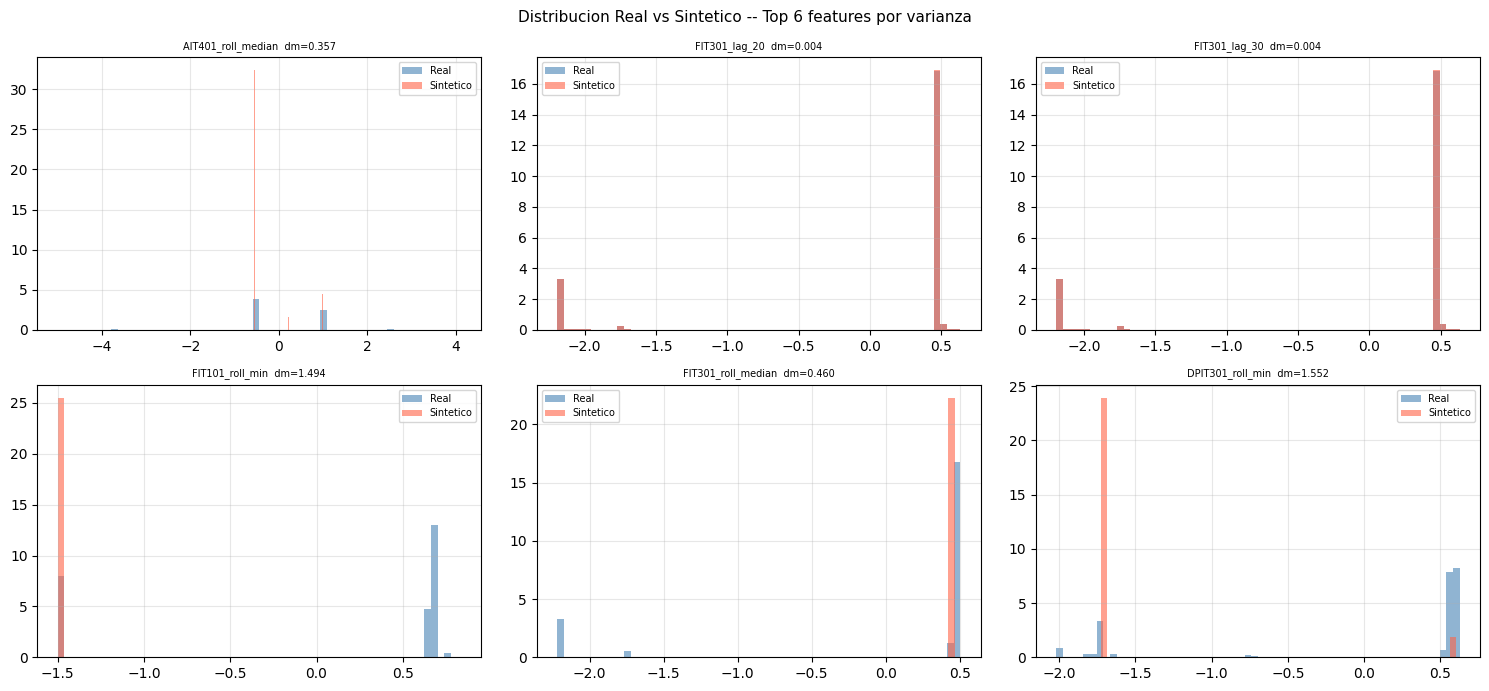

In [8]:
var_r  = X_tr_c.reshape(-1, X_tr_c.shape[2]).var(axis=0)
top6   = np.argsort(var_r)[-6:][::-1]
rf     = X_tr_c.reshape(-1, X_tr_c.shape[2])
sf     = X_sy_c.reshape(-1, X_sy_c.shape[2])
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, idx in zip(axes.flat, top6):
    nm = CONT_FEAT_COLS[idx]
    ax.hist(rf[:,idx], bins=60, alpha=0.6, density=True, color='steelblue', label='Real')
    ax.hist(sf[:,idx], bins=60, alpha=0.6, density=True, color='tomato',    label='Sintetico')
    dm = abs(rf[:,idx].mean() - sf[:,idx].mean())
    ax.set_title(f'{nm[:18]}  dm={dm:.3f}', fontsize=7)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('Distribucion Real vs Sintetico -- Top 6 features por varianza', fontsize=11)
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'dist_real_vs_synth.png'), dpi=120, bbox_inches='tight')
plt.show()


## 6. Arquitectura LSTM-VAE Hibrida (identica al baseline_v3)

In [9]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm     = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0.0)
        self.drop     = nn.Dropout(dropout)
        self.fc_mu    = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len; self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, seq_len, disc_dim, hidden_size, num_layers, latent_dim, disc_hidden, dropout):
        super().__init__()
        cont_size = len(CONT_FEAT_COLS)
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def build_model():
    return HybridLSTMVAE(
        seq_len=WINDOW_SIZE, disc_dim=DISC_DIM, hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS, latent_dim=LATENT_DIM,
        disc_hidden=DISC_HIDDEN, dropout=DROPOUT
    ).to(device)

n_params = sum(p.numel() for p in build_model().parameters())
print(f'Parametros por modelo: {n_params:,}')
print(f'Input: (N, {WINDOW_SIZE}, {len(CONT_FEAT_COLS)}) cont + (N, {DISC_DIM}) disc')


Parametros por modelo: 2,090,377
Input: (N, 10, 89) cont + (N, 104) disc


## 7. Funciones de entrenamiento y evaluacion

In [10]:
def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha*(mse_c + beta*kl) + (1-alpha)*mse_d, mse_c, mse_d, kl

def train_model(Xc_train, Xd_train, label):
    """Val SIEMPRE = X_va_c/X_va_d (20% Normal_v1) -- identico en los 3 escenarios."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = build_model()
    tr_loader = DataLoader(
        TensorDataset(torch.tensor(Xc_train, dtype=torch.float32),
                      torch.tensor(Xd_train, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    va_loader = DataLoader(
        TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                      torch.tensor(X_va_d, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=8, min_lr=1e-7)
    best_val = float('inf'); best_wts = None; no_imp = 0; best_ep = 1
    tr_hist = []; va_hist = []
    print(f'\n[{label}] {len(Xc_train):,} train | {len(X_va_c):,} val | batch={BATCH_SIZE}')
    for ep in range(1, MAX_EPOCHS+1):
        model.train()
        tl = 0.0
        for xc_b, xd_b in tr_loader:
            xc_b, xd_b = xc_b.to(device), xd_b.to(device)
            opt.zero_grad()
            xc_h, xd_h, mu, lv = model(xc_b, xd_b)
            loss = elbo_loss(xc_b, xc_h, xd_b, xd_h, mu, lv, ALPHA, BETA)[0]
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tl += loss.item()
        tl /= len(tr_loader)
        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xc_b, xd_b in va_loader:
                xc_b, xd_b = xc_b.to(device), xd_b.to(device)
                xc_h, xd_h, mu, lv = model(xc_b, xd_b)
                vl += elbo_loss(xc_b, xc_h, xd_b, xd_h, mu, lv, ALPHA, BETA)[0].item()
        vl /= len(va_loader)
        sched.step(vl)
        tr_hist.append(tl); va_hist.append(vl)
        if vl < best_val - 1e-7:
            best_val = vl; best_ep = ep; no_imp = 0
            best_wts = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
        if ep % 10 == 0:
            print(f'  Ep {ep:4d} | Train:{tl:.5f} | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
        if no_imp >= PATIENCE:
            print(f'  Early stop ep{ep}.'); break
    model.load_state_dict(best_wts); model.eval()
    print(f'  Mejor val:{best_val:.5f} ep{best_ep}')
    return model, tr_hist, va_hist, best_ep, best_val

def recon_scores(model, Xc, Xd, bs=512):
    ldr = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                   torch.tensor(Xd, dtype=torch.float32)),
                     batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc_b, xd_b in ldr:
            xc_b, xd_b = xc_b.to(device), xd_b.to(device)
            xc_h, xd_h, mu, _ = model(xc_b, xd_b)
            ec_l.extend(torch.mean(torch.abs(xc_h-xc_b), dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean(torch.abs(xd_h-xd_b), dim=1).cpu().numpy())
    return ALPHA*np.array(ec_l) + (1-ALPHA)*np.array(ed_l)

def consec_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out

def find_tau_pc(sc_filt, y_filt, min_prec):
    """Umbral PC: max recall con Precision >= min_prec (metodo baseline_v3)."""
    taus = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
    sw_p, sw_r, sw_f1, sw_fpr = [], [], [], []
    for tau in taus:
        pr  = consec_filter(sc_filt, tau, CONSEC_K)
        tp_ = ((pr==1)&(y_filt==1)).sum(); fp_ = ((pr==1)&(y_filt==0)).sum()
        fn_ = ((pr==0)&(y_filt==1)).sum(); tn_ = ((pr==0)&(y_filt==0)).sum()
        p_  = tp_/(tp_+fp_+1e-10); r_ = tp_/(tp_+fn_+1e-10)
        sw_p.append(p_); sw_r.append(r_)
        sw_f1.append(2*p_*r_/(p_+r_+1e-10))
        sw_fpr.append(fp_/(fp_+tn_+1e-10))
    sw_p_arr = np.array(sw_p); sw_r_arr = np.array(sw_r)
    sw_f1_arr = np.array(sw_f1)
    # tau_F1
    tau_f1 = float(taus[sw_f1_arr.argmax()])
    # tau_PC (max recall con prec >= min_prec)
    valid = sw_p_arr >= min_prec
    tau_pc = float(taus[np.argmax(np.where(valid, sw_r_arr, -1.0))]) if valid.any() else tau_f1
    # tau_F2
    sw_fb = (1+4)*sw_p_arr*sw_r_arr/((4)*sw_p_arr+sw_r_arr+1e-10)
    tau_f2 = float(taus[sw_fb.argmax()])
    return tau_f1, tau_pc, tau_f2, taus, sw_f1_arr, sw_p_arr, sw_r_arr, np.array(sw_fpr)

def metrics_at_tau(sc_filt, y_filt, tau):
    pr = consec_filter(sc_filt, tau, CONSEC_K)
    tp = int(((pr==1)&(y_filt==1)).sum()); fp = int(((pr==1)&(y_filt==0)).sum())
    fn = int(((pr==0)&(y_filt==1)).sum()); tn = int(((pr==0)&(y_filt==0)).sum())
    prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
    return {'tau': float(tau), 'f1': 2*prec*rec/(prec+rec+1e-10),
            'recall': rec, 'precision': prec, 'fpr': fp/(fp+tn+1e-10),
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

def evaluate_full(model, Xev_c, Xev_d, y_ev, df_ev):
    """Evaluacion completa: 3 umbrales + conteo de ataques."""
    sc = recon_scores(model, Xev_c, Xev_d)
    assert len(sc) == len(y_ev)
    mn = sc[y_ev==0].mean(); ma = sc[y_ev==1].mean() if (y_ev==1).any() else 0.0
    auc_all = roc_auc_score(y_ev, sc)
    # Filtrar ataques no evaluables
    keep = ~((df_ev['y'].values==1) & (~np.isin(df_ev['attack_id'].values, EVALUABLE_ATK_IDS)))
    sc_f = sc[keep]; y_f = y_ev[keep]
    auc_26  = float(roc_auc_score(y_f, sc_f))
    pr_auc  = float(average_precision_score(y_f, sc_f))
    tau_f1, tau_pc, tau_f2, taus, sw_f1, sw_p, sw_r, sw_fpr = find_tau_pc(sc_f, y_f, MIN_PREC)
    m_f1 = metrics_at_tau(sc_f, y_f, tau_f1)
    m_pc = metrics_at_tau(sc_f, y_f, tau_pc)
    m_f2 = metrics_at_tau(sc_f, y_f, tau_f2)
    # Conteo de ataques por umbral
    pred_full_f1 = consec_filter(sc, tau_f1, CONSEC_K)
    pred_full_pc = consec_filter(sc, tau_pc, CONSEC_K)
    pred_full_f2 = consec_filter(sc, tau_f2, CONSEC_K)
    df_ev_tmp = df_ev.copy()
    df_ev_tmp['pred_f1'] = pred_full_f1
    df_ev_tmp['pred_pc'] = pred_full_pc
    df_ev_tmp['pred_f2'] = pred_full_f2
    det = {}
    for tau_lbl in ['pred_f1', 'pred_pc', 'pred_f2']:
        det[tau_lbl] = sum(
            1 for aid in EVALUABLE_ATK_IDS
            if df_ev_tmp.loc[df_ev_tmp['attack_id']==aid, tau_lbl].sum() > 0
        )
    return {
        'roc_auc_all': float(auc_all), 'roc_auc': auc_26, 'pr_auc': pr_auc,
        'ratio': float(ma/mn) if mn > 0 else 0.0,
        'f1_tau': m_f1, 'pc_tau': m_pc, 'f2_tau': m_f2,
        'det_f1': det['pred_f1'], 'det_pc': det['pred_pc'], 'det_f2': det['pred_f2'],
        'sc_all': sc, 'sc_filt': sc_f, 'y_filt': y_f,
        'taus': taus, 'sw_f1': sw_f1, 'sw_p': sw_p, 'sw_r': sw_r, 'sw_fpr': sw_fpr,
        'df_ev_tmp': df_ev_tmp,
    }

print('Funciones definidas: train_model, recon_scores, consec_filter, ')
print('  find_tau_pc, metrics_at_tau, evaluate_full')


Funciones definidas: train_model, recon_scores, consec_filter, 
  find_tau_pc, metrics_at_tau, evaluate_full


## 8. Ventanas de evaluacion (Attack_v0, stride=1)

In [11]:
# Cargar lista de ataques y parsear timestamps
df_atk_list = pd.read_excel(ATK_LIST)
df_atk_list = df_atk_list[
    pd.to_numeric(df_atk_list['Attack #'], errors='coerce').notna()
].copy()
df_atk_list['Attack #'] = df_atk_list['Attack #'].astype(int)
df_atk_list['start_dt'] = pd.to_datetime(
    df_atk_list['Start Time'].astype(str).str.strip(), errors='coerce'
)
def parse_end(row):
    et = str(row['End Time']).strip()
    if et in ('nan','NaT',''): return pd.NaT
    st = row['start_dt']
    if pd.isna(st): return pd.NaT
    try:
        t   = pd.to_datetime(et, format='%H:%M:%S').time()
        end = pd.Timestamp.combine(st.date(), t)
        return end + pd.Timedelta(days=1) if end < st else end
    except: return pd.NaT
df_atk_list['end_dt'] = df_atk_list.apply(parse_end, axis=1)

# Cargar y preprocesar Attack_v0
df_attack = load_swat_xlsx(ATTACK_XLSX, label_is_string=True)
df_attack_fe = add_feat_eng(df_attack)

df_eval_sc = df_attack_fe.copy()
df_eval_sc[CONT_FEAT_COLS] = np.clip(
    scaler_cont.transform(df_eval_sc[CONT_FEAT_COLS].values), -CLIP_VAL, CLIP_VAL
)
df_eval_sc[DISCRETE_COLS] = (df_eval_sc[DISCRETE_COLS] / disc_max).clip(0, 1)

# Asignar attack_id por timestamps
df_eval_sc['attack_id'] = 0
for _, row in df_atk_list.iterrows():
    aid = int(row['Attack #'])
    if pd.isna(row['start_dt']) or pd.isna(row['end_dt']): continue
    mask = ((df_eval_sc['Timestamp'] >= row['start_dt']) &
            (df_eval_sc['Timestamp'] <= row['end_dt']))
    df_eval_sc.loc[mask, 'attack_id'] = aid

# Construir ventanas eval con stride=1
cont_arr = df_eval_sc[CONT_FEAT_COLS].values.astype(np.float32)
disc_arr = df_eval_sc[DISCRETE_COLS].values.astype(np.float32)
labs_arr = df_eval_sc['attack_label'].values
aid_arr  = df_eval_sc['attack_id'].values
ts_arr   = df_eval_sc['Timestamp'].values

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE_EVAL):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    atk_aids = seg_aids[seg_labs==1]
    if len(atk_aids) > 0:
        uid, cnt = np.unique(atk_aids, return_counts=True)
        aid_mode = int(uid[cnt.argmax()])
    else:
        aid_mode = 0
    meta_rows.append({'y': int(np.any(seg_labs==1)), 'attack_id': aid_mode,
                      'attack_frac': float(np.mean(seg_labs==1)), 't_start': ts_arr[s]})

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), DISCRETE_COLS)
df_wins  = pd.DataFrame(meta_rows)
y_all    = df_wins['y'].values

print(f'Ventanas eval (stride={STRIDE_EVAL}): {len(df_wins):,}')
print(f'  Normal: {(y_all==0).sum():,} | Ataque: {(y_all==1).sum():,}  ({100*y_all.mean():.1f}%)')
assert len(X_eval_c) == len(y_all)
print('Shape OK')


Ventanas eval (stride=1): 449,910
  Normal: 394,974 | Ataque: 54,936  (12.2%)
Shape OK


## 9. Escenario 1 -- real_only (identico a baseline_v3)

In [12]:
m_real, h_tr_r, h_va_r, ep_r, val_r = train_model(X_tr_c, X_tr_d, 'real_only')
torch.save(m_real.state_dict(), TSTR_DIR / 'model_real_only.pt')
print('Guardado: model_real_only.pt')



[real_only] 226,191 train | 75,391 val | batch=1024
  Ep   10 | Train:0.08292 | Val:0.09570 | Best:0.09570(ep10)
  Ep   20 | Train:0.06409 | Val:0.08070 | Best:0.08070(ep20)
  Ep   30 | Train:0.05683 | Val:0.07503 | Best:0.07304(ep28)
  Ep   40 | Train:0.05323 | Val:0.07068 | Best:0.07068(ep40)
  Ep   50 | Train:0.05117 | Val:0.06687 | Best:0.06687(ep50)
  Ep   60 | Train:0.04985 | Val:0.06670 | Best:0.06545(ep58)
  Ep   70 | Train:0.04889 | Val:0.06408 | Best:0.06408(ep70)
  Ep   80 | Train:0.04830 | Val:0.06304 | Best:0.06304(ep80)
  Ep   90 | Train:0.04809 | Val:0.06350 | Best:0.06281(ep89)
  Ep  100 | Train:0.04732 | Val:0.06312 | Best:0.06264(ep97)
  Ep  110 | Train:0.04672 | Val:0.06248 | Best:0.06248(ep110)
  Ep  120 | Train:0.04632 | Val:0.06340 | Best:0.06212(ep113)
  Ep  130 | Train:0.04610 | Val:0.06214 | Best:0.06212(ep113)
  Early stop ep133.
  Mejor val:0.06212 ep113
Guardado: model_real_only.pt


## 10. Escenario 2 -- synthetic_only

In [13]:
m_synth, h_tr_s, h_va_s, ep_s, val_s = train_model(X_sy_c, X_sy_d, 'synthetic_only')
torch.save(m_synth.state_dict(), TSTR_DIR / 'model_synthetic_only.pt')
print('Guardado: model_synthetic_only.pt')



[synthetic_only] 33,930 train | 75,391 val | batch=1024
  Ep   10 | Train:0.51121 | Val:1.33999 | Best:1.11703(ep1)
  Ep   20 | Train:0.48089 | Val:1.33959 | Best:1.11703(ep1)
  Early stop ep21.
  Mejor val:1.11703 ep1
Guardado: model_synthetic_only.pt


## 11. Escenario 3 -- real_plus_synthetic

In [14]:
X_co_c = np.concatenate([X_tr_c, X_sy_c], axis=0)
X_co_d = np.concatenate([X_tr_d, X_sy_d], axis=0)
print(f'Combined: {len(X_co_c):,} (real={len(X_tr_c):,} + synth={len(X_sy_c):,})')
print(f'Proporcion real: {100*len(X_tr_c)/len(X_co_c):.1f}%')
m_comb, h_tr_c, h_va_c, ep_c, val_c = train_model(X_co_c, X_co_d, 'real_plus_synthetic')
torch.save(m_comb.state_dict(), TSTR_DIR / 'model_real_plus_synthetic.pt')
print('Guardado: model_real_plus_synthetic.pt')


Combined: 260,121 (real=226,191 + synth=33,930)
Proporcion real: 87.0%

[real_plus_synthetic] 260,121 train | 75,391 val | batch=1024
  Ep   10 | Train:0.12761 | Val:0.09659 | Best:0.09659(ep10)
  Ep   20 | Train:0.10395 | Val:0.07938 | Best:0.07938(ep20)
  Ep   30 | Train:0.09496 | Val:0.07024 | Best:0.07024(ep30)
  Ep   40 | Train:0.08964 | Val:0.06634 | Best:0.06634(ep40)
  Ep   50 | Train:0.08612 | Val:0.06371 | Best:0.06371(ep50)
  Ep   60 | Train:0.08396 | Val:0.06276 | Best:0.06267(ep58)
  Ep   70 | Train:0.08246 | Val:0.06102 | Best:0.06102(ep70)
  Ep   80 | Train:0.08098 | Val:0.06157 | Best:0.06050(ep78)
  Ep   90 | Train:0.07988 | Val:0.06022 | Best:0.06022(ep90)
  Ep  100 | Train:0.07896 | Val:0.06004 | Best:0.05983(ep94)
  Ep  110 | Train:0.07810 | Val:0.05971 | Best:0.05957(ep108)
  Ep  120 | Train:0.07745 | Val:0.05980 | Best:0.05910(ep119)
  Ep  130 | Train:0.07690 | Val:0.05938 | Best:0.05883(ep122)
  Ep  140 | Train:0.07651 | Val:0.05891 | Best:0.05854(ep139)
  Ep  15

## 12. Curvas de entrenamiento

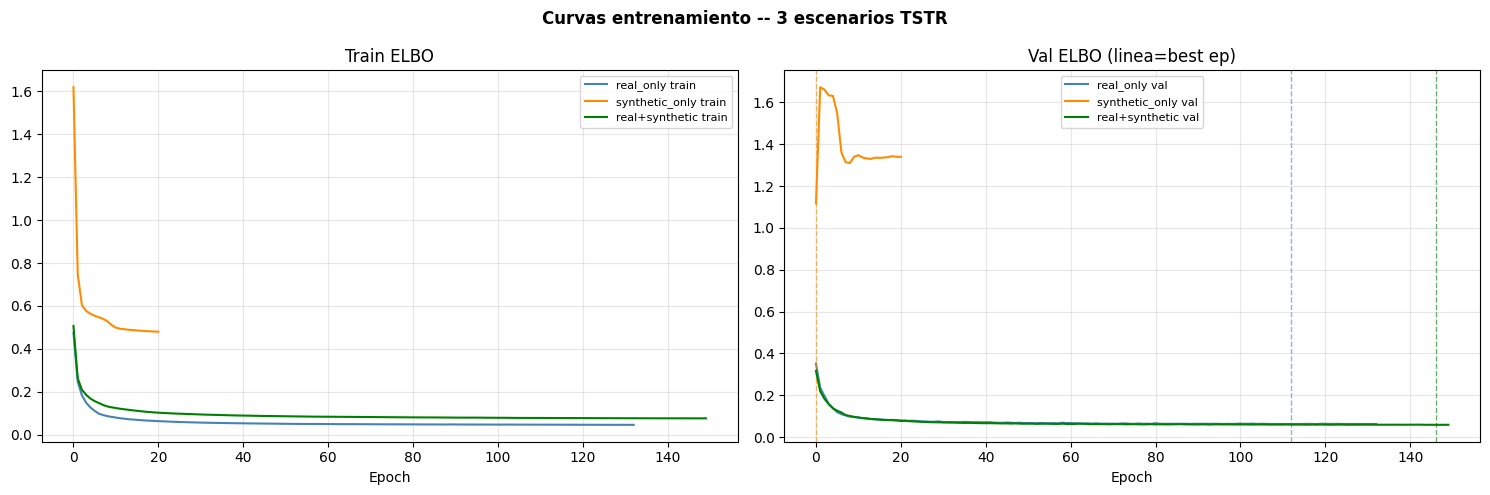

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for h_tr, h_va, ep, lbl, col in [
    (h_tr_r, h_va_r, ep_r, 'real_only',      'steelblue'),
    (h_tr_s, h_va_s, ep_s, 'synthetic_only', 'darkorange'),
    (h_tr_c, h_va_c, ep_c, 'real+synthetic', 'green'),
]:
    axes[0].plot(h_tr, lw=1.5, color=col, label=f'{lbl} train')
    axes[1].plot(h_va, lw=1.5, color=col, label=f'{lbl} val')
    axes[1].axvline(ep-1, color=col, lw=1, linestyle='--', alpha=0.6)
for ax, ttl in zip(axes, ['Train ELBO', 'Val ELBO (linea=best ep)']):
    ax.set_title(ttl); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Curvas entrenamiento -- 3 escenarios TSTR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


## 13. Recargar modelos y evaluar

Los modelos se recargan del disco para estado limpio.
Evaluacion con los 3 umbrales: F1, PC (Prec>=MIN_PREC), F2.


In [16]:
m_real_ev = build_model()
m_real_ev.load_state_dict(torch.load(TSTR_DIR / 'model_real_only.pt', map_location=device))
m_real_ev.eval()
m_synth_ev = build_model()
m_synth_ev.load_state_dict(torch.load(TSTR_DIR / 'model_synthetic_only.pt', map_location=device))
m_synth_ev.eval()
m_comb_ev = build_model()
m_comb_ev.load_state_dict(torch.load(TSTR_DIR / 'model_real_plus_synthetic.pt', map_location=device))
m_comb_ev.eval()
print('Modelos recargados del disco OK')
print(f'Datos eval: X_eval_c={X_eval_c.shape} | y_all={len(y_all)}')
assert len(X_eval_c) == len(y_all) == len(df_wins)


Modelos recargados del disco OK
Datos eval: X_eval_c=(449910, 10, 89) | y_all=449910


In [17]:
R_KEYS = ['real_only', 'synthetic_only', 'real_plus_synthetic']
RES    = {}
print(f'Evaluando (26 ataques Pinto | k={CONSEC_K} | MIN_PREC={MIN_PREC})\n')
for mdl, lbl in [
    (m_real_ev,  'real_only'),
    (m_synth_ev, 'synthetic_only'),
    (m_comb_ev,  'real_plus_synthetic'),
]:
    RES[lbl] = evaluate_full(mdl, X_eval_c, X_eval_d, y_all, df_wins)
    r = RES[lbl]
    print(f'  [{lbl}]')
    print(f'    AUC={r["roc_auc"]:.4f} | PR-AUC={r["pr_auc"]:.4f} | ratio={r["ratio"]:.2f}x')
    print(f'    tau_F1({r["f1_tau"]["tau"]:.3f}): F1={r["f1_tau"]["f1"]:.3f} Rec={r["f1_tau"]["recall"]:.3f} Prec={r["f1_tau"]["precision"]:.3f} | det={r["det_f1"]}/26')
    print(f'    tau_PC({r["pc_tau"]["tau"]:.3f}): F1={r["pc_tau"]["f1"]:.3f} Rec={r["pc_tau"]["recall"]:.3f} Prec={r["pc_tau"]["precision"]:.3f} | det={r["det_pc"]}/26  <-- principal')
    print(f'    tau_F2({r["f2_tau"]["tau"]:.3f}): F1={r["f2_tau"]["f1"]:.3f} Rec={r["f2_tau"]["recall"]:.3f} Prec={r["f2_tau"]["precision"]:.3f} | det={r["det_f2"]}/26')
    print()


Evaluando (26 ataques Pinto | k=3 | MIN_PREC=0.712)

  [real_only]
    AUC=0.9393 | PR-AUC=0.7856 | ratio=2.21x
    tau_F1(0.884): F1=0.796 Rec=0.702 Prec=0.917 | det=11/26
    tau_PC(0.674): F1=0.738 Rec=0.761 Prec=0.716 | det=18/26  <-- principal
    tau_F2(0.612): F1=0.694 Rec=0.809 Prec=0.607 | det=19/26

  [synthetic_only]
    AUC=0.8901 | PR-AUC=0.8015 | ratio=1.57x
    tau_F1(1.769): F1=0.793 Rec=0.657 Prec=0.999 | det=1/26
    tau_PC(1.370): F1=0.729 Rec=0.742 Prec=0.717 | det=10/26  <-- principal
    tau_F2(1.391): F1=0.747 Rec=0.735 Prec=0.760 | det=10/26

  [real_plus_synthetic]
    AUC=0.9215 | PR-AUC=0.7036 | ratio=1.94x
    tau_F1(0.942): F1=0.784 Rec=0.704 Prec=0.885 | det=15/26
    tau_PC(0.812): F1=0.727 Rec=0.741 Prec=0.714 | det=17/26  <-- principal
    tau_F2(0.900): F1=0.777 Rec=0.723 Prec=0.839 | det=15/26



## 14. Tabla comparativa (umbral PC como principal)

In [18]:
n_wins_map = {'real_only': len(X_tr_c), 'synthetic_only': len(X_sy_c),
               'real_plus_synthetic': len(X_co_c)}
rows = []
for lbl in R_KEYS:
    r = RES[lbl]; m = r['pc_tau']
    rows.append({
        'Escenario': lbl, 'Train_wins': n_wins_map[lbl],
        'AUC': round(r['roc_auc'], 4), 'PR-AUC': round(r['pr_auc'], 4),
        'F1': round(m['f1'], 3), 'Recall': round(m['recall'], 3),
        'Precision': round(m['precision'], 3), 'FPR': round(m['fpr'], 3),
        'tau_PC': round(m['tau'], 5),
        'Ataques_det': r['det_pc'], 'TP': m['tp'], 'FP': m['fp'], 'FN': m['fn'],
    })
df_comp = pd.DataFrame(rows)
print('Tabla comparativa (tau PC -- Prec >= MIN_PREC):')
print(df_comp.to_string(index=False))
print()
base = RES['real_only']; bm = base['pc_tau']
print('Delta vs real_only (tau PC):')
for lbl in ['synthetic_only', 'real_plus_synthetic']:
    r = RES[lbl]; m = r['pc_tau']
    print(f'  {lbl:<25}: DAUC={r["roc_auc"]-base["roc_auc"]:+.4f} | '
          f'DF1={m["f1"]-bm["f1"]:+.3f} | DRec={m["recall"]-bm["recall"]:+.3f} | '
          f'Ddet={r["det_pc"]-base["det_pc"]:+d}')
print()
print(f'Referencia Pinto et al.: AUC=0.87 | F1=0.74 | Rec=0.78 | Prec=0.70 | det=23/26')
df_comp.to_csv(TSTR_DIR / 'tabla_comparativa.csv', index=False)


Tabla comparativa (tau PC -- Prec >= MIN_PREC):
          Escenario  Train_wins    AUC  PR-AUC    F1  Recall  Precision   FPR  tau_PC  Ataques_det    TP    FP    FN
          real_only      226191 0.9393  0.7856 0.738   0.761      0.716 0.037 0.67416           18 36925 14616 11570
     synthetic_only       33930 0.8901  0.8015 0.729   0.742      0.717 0.036 1.37023           10 35967 14193 12528
real_plus_synthetic      260121 0.9215  0.7036 0.727   0.741      0.714 0.036 0.81170           17 35928 14389 12567

Delta vs real_only (tau PC):
  synthetic_only           : DAUC=-0.0491 | DF1=-0.009 | DRec=-0.020 | Ddet=-8
  real_plus_synthetic      : DAUC=-0.0177 | DF1=-0.011 | DRec=-0.021 | Ddet=-1

Referencia Pinto et al.: AUC=0.87 | F1=0.74 | Rec=0.78 | Prec=0.70 | det=23/26


## 15. Graficos comparativos

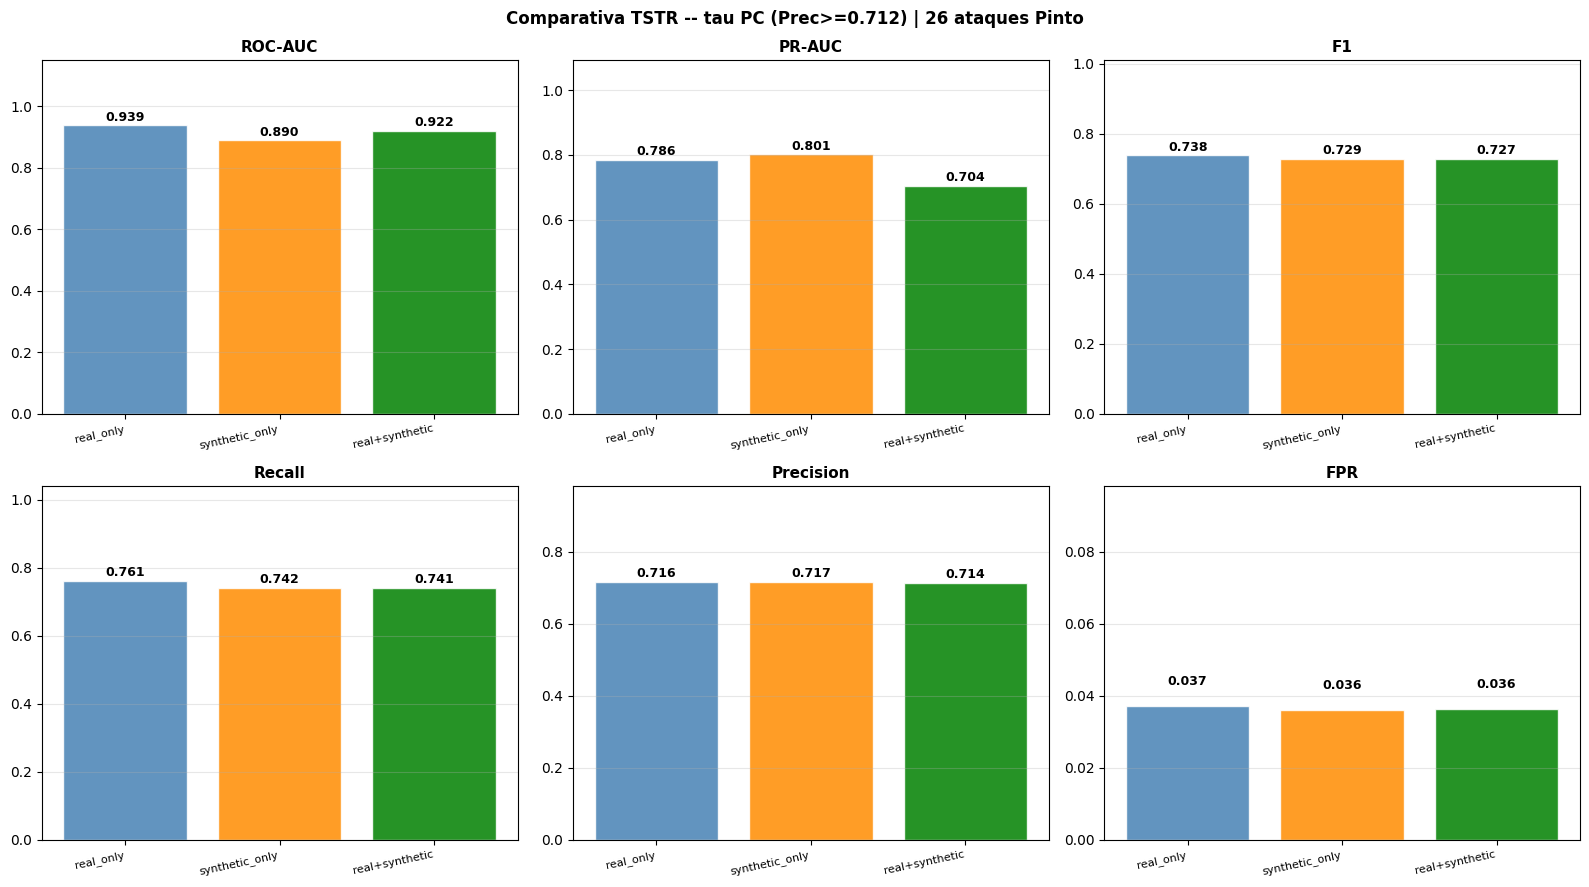

In [19]:
colors_sc = ['steelblue', 'darkorange', 'green']
labels_sc  = ['real_only', 'synthetic_only', 'real+synthetic']
# Metricas en tau_PC
met_keys   = ['roc_auc', 'pr_auc', 'f1', 'recall', 'precision', 'fpr']
met_labels = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision', 'FPR']

def get_m(lbl, mk):
    r = RES[lbl]
    if mk in ('roc_auc', 'pr_auc', 'ratio'): return r[mk]
    return r['pc_tau'][mk]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, mk, ml in zip(axes.flat, met_keys, met_labels):
    vals = [get_m(lbl, mk) for lbl in R_KEYS]
    bars = ax.bar(labels_sc, vals, color=colors_sc, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(ml, fontsize=11, fontweight='bold')
    ax.set_ylim(0, min(1.15, max(vals)*1.3+0.05))
    ax.set_xticklabels(labels_sc, rotation=12, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle(f'Comparativa TSTR -- tau PC (Prec>={MIN_PREC}) | 26 ataques Pinto',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'metricas_comparativas.png'), dpi=130, bbox_inches='tight')
plt.show()


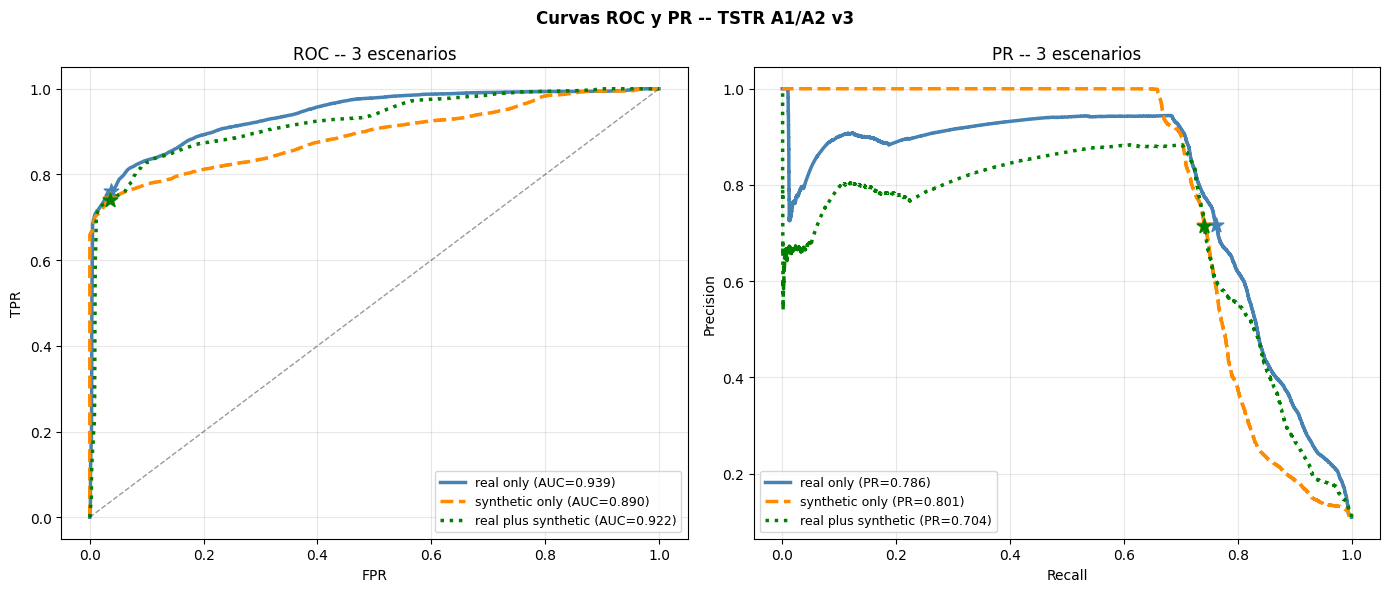

In [20]:
# ROC y PR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for lbl, col, sty in zip(R_KEYS, colors_sc, ['-','--',':']):
    r = RES[lbl]; m = r['pc_tau']
    fp_, tp_, _ = roc_curve(r['y_filt'], r['sc_filt'])
    pr_, re_, _ = precision_recall_curve(r['y_filt'], r['sc_filt'])
    axes[0].plot(fp_, tp_, lw=2.5, color=col, linestyle=sty,
                 label=f'{lbl.replace("_"," ")} (AUC={r["roc_auc"]:.3f})')
    axes[0].scatter(m['fpr'], m['recall'], s=120, color=col, zorder=5, marker='*')
    axes[1].plot(re_, pr_, lw=2.5, color=col, linestyle=sty,
                 label=f'{lbl.replace("_"," ")} (PR={r["pr_auc"]:.3f})')
    axes[1].scatter(m['recall'], m['precision'], s=120, color=col, zorder=5, marker='*')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC -- 3 escenarios'); axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.3)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR -- 3 escenarios'); axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.3)
plt.suptitle('Curvas ROC y PR -- TSTR A1/A2 v3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'roc_pr_comparison.png'), dpi=130, bbox_inches='tight')
plt.show()


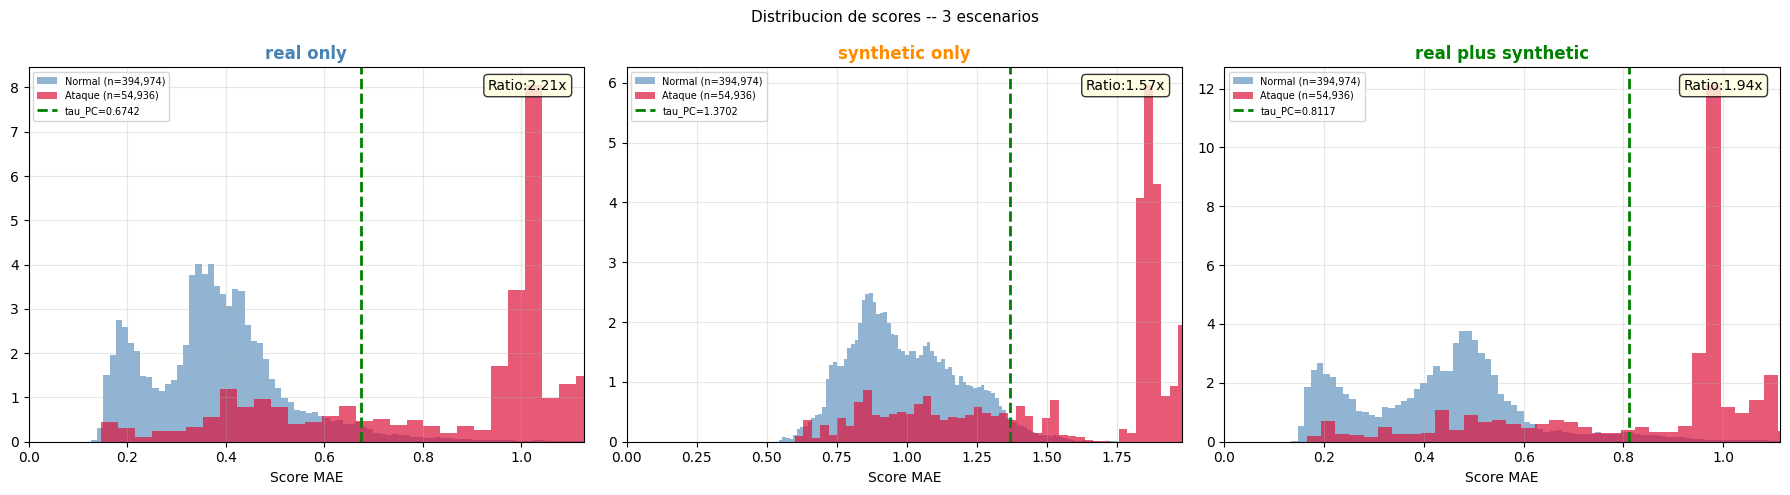

In [21]:
# Distribucion de scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl, col in zip(axes, R_KEYS, colors_sc):
    sc = RES[lbl]['sc_all']; tau = RES[lbl]['pc_tau']['tau']
    ax.hist(sc[y_all==0], bins=100, alpha=0.6, density=True, color='steelblue',
            label=f'Normal (n={(y_all==0).sum():,})')
    ax.hist(sc[y_all==1], bins=50, alpha=0.7, density=True, color='crimson',
            label=f'Ataque (n={(y_all==1).sum():,})')
    ax.axvline(tau, color='green', lw=2, linestyle='--', label=f'tau_PC={tau:.4f}')
    ax.text(0.97, 0.97, f'Ratio:{RES[lbl]["ratio"]:.2f}x', ha='right', va='top',
            transform=ax.transAxes, bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
    ax.set_title(lbl.replace('_',' '), color=col, fontweight='bold')
    ax.set_xlabel('Score MAE'); ax.legend(fontsize=7); ax.grid(True,alpha=0.3)
    ax.set_xlim(0, np.percentile(sc, 99.5))
plt.suptitle('Distribucion de scores -- 3 escenarios', fontsize=11)
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'score_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


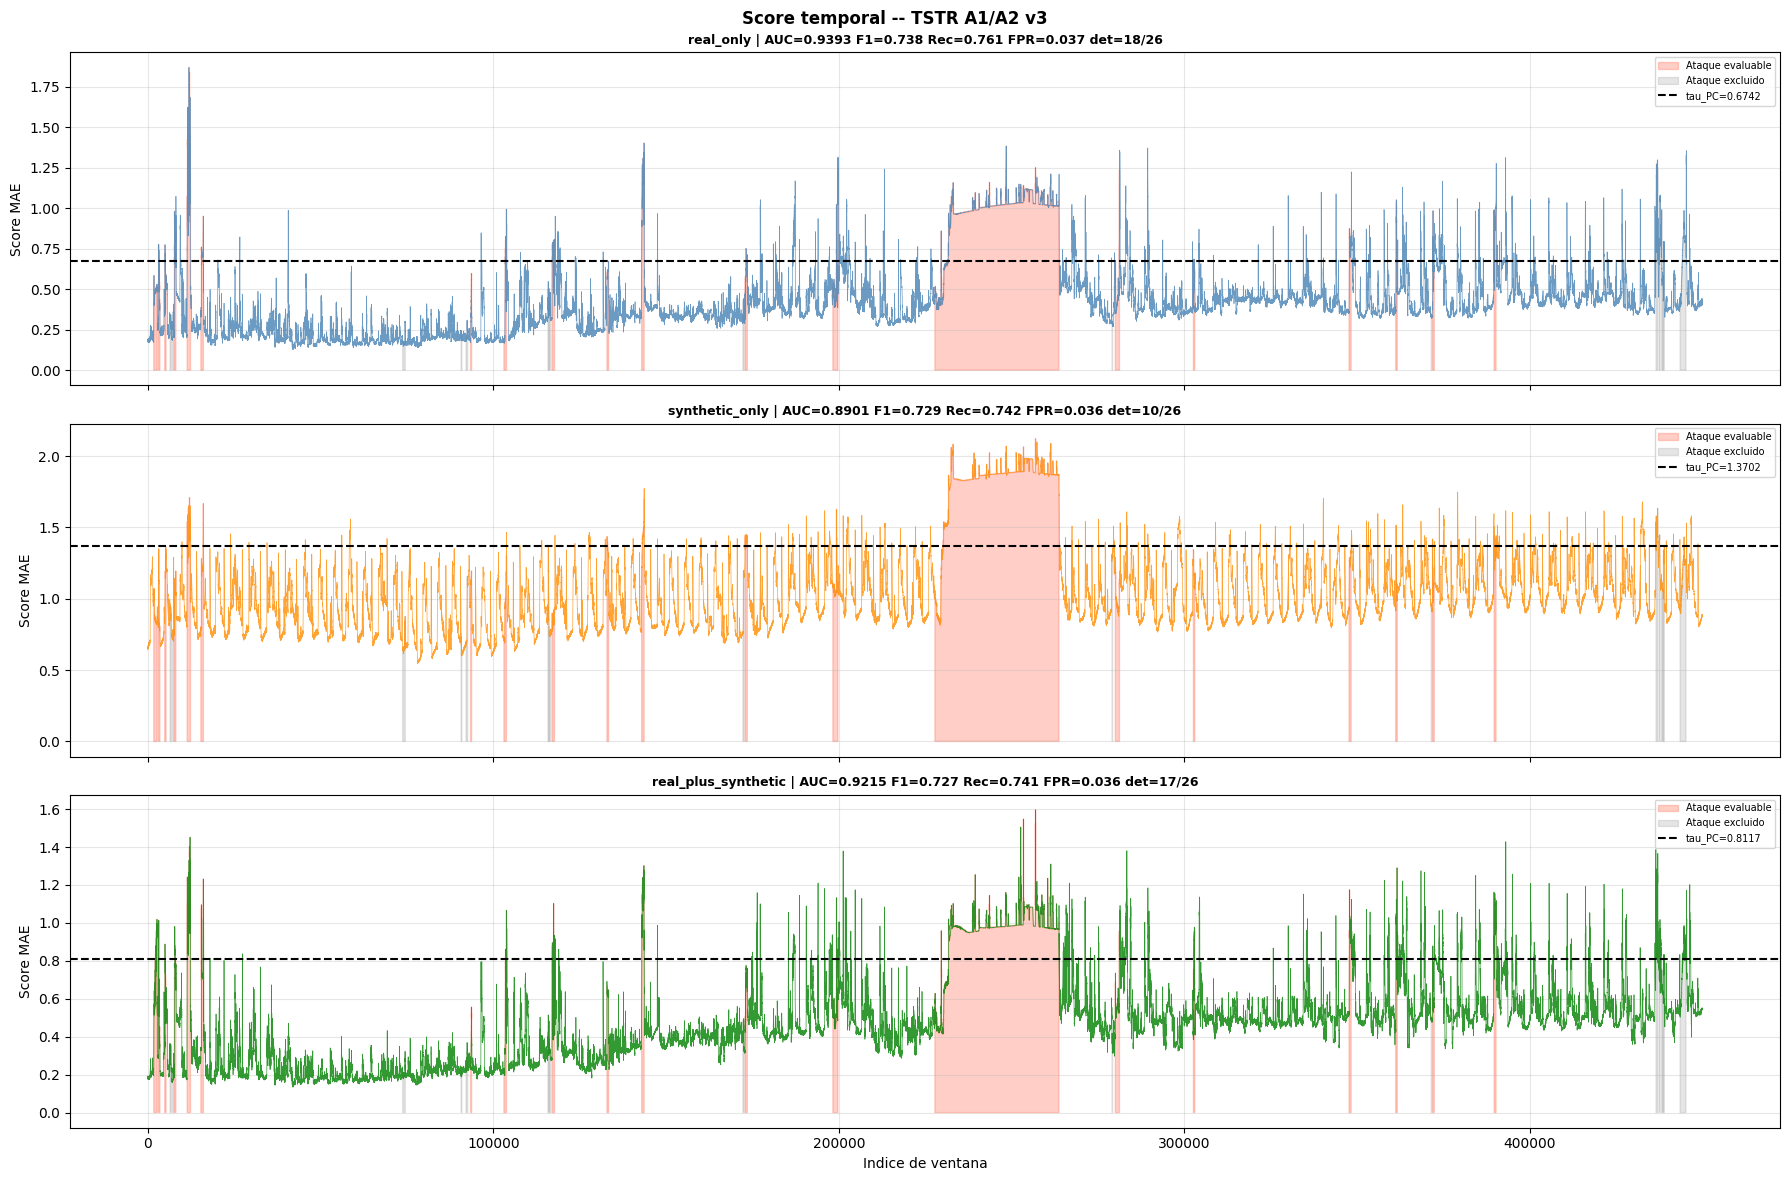

In [22]:
# Score temporal
t_idx     = np.arange(len(df_wins))
excl_mask = ((df_wins['y']==1) & (~df_wins['attack_id'].isin(EVALUABLE_ATK_IDS))).values
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
for ax, lbl, col in zip(axes, R_KEYS, colors_sc):
    sc  = RES[lbl]['sc_all']; tau = RES[lbl]['pc_tau']['tau']
    ax.plot(t_idx, sc, color=col, lw=0.5, alpha=0.8)
    ax.fill_between(t_idx, 0, sc, where=(y_all==1)&~excl_mask,
                    color='tomato', alpha=0.30, label='Ataque evaluable')
    ax.fill_between(t_idx, 0, sc, where=excl_mask,
                    color='gray', alpha=0.20, label='Ataque excluido')
    ax.axhline(tau, color='black', lw=1.5, linestyle='--', label=f'tau_PC={tau:.4f}')
    r = RES[lbl]['pc_tau']
    ax.set_title(f'{lbl} | AUC={RES[lbl]["roc_auc"]:.4f} F1={r["f1"]:.3f} '
                 f'Rec={r["recall"]:.3f} FPR={r["fpr"]:.3f} det={RES[lbl]["det_pc"]}/26',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Score MAE'); ax.legend(fontsize=7, loc='upper right'); ax.grid(True,alpha=0.3)
axes[-1].set_xlabel('Indice de ventana')
plt.suptitle('Score temporal -- TSTR A1/A2 v3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'score_temporal.png'), dpi=130, bbox_inches='tight')
plt.show()


 attack_id     n  det_real_only  det_synthetic_only  det_real_plus_synthetic
         1   949            0.0                 0.0                     33.1
         2   452           10.6                 0.0                      4.6
         3   392           13.8                 0.0                      6.6
         7   438           89.7                 0.0                     42.5
         8   973           99.7                83.5                     97.3
        10   165            1.2                 0.0                      0.0
        11   565           89.4                 7.8                     24.1
        16   285            0.0                 0.0                      0.0
        17   726           25.5                 0.0                     12.4
        21   730           69.6                 0.0                      4.9
        22   472            0.0                38.8                      0.0
        23   706           99.7                76.1                     98.0

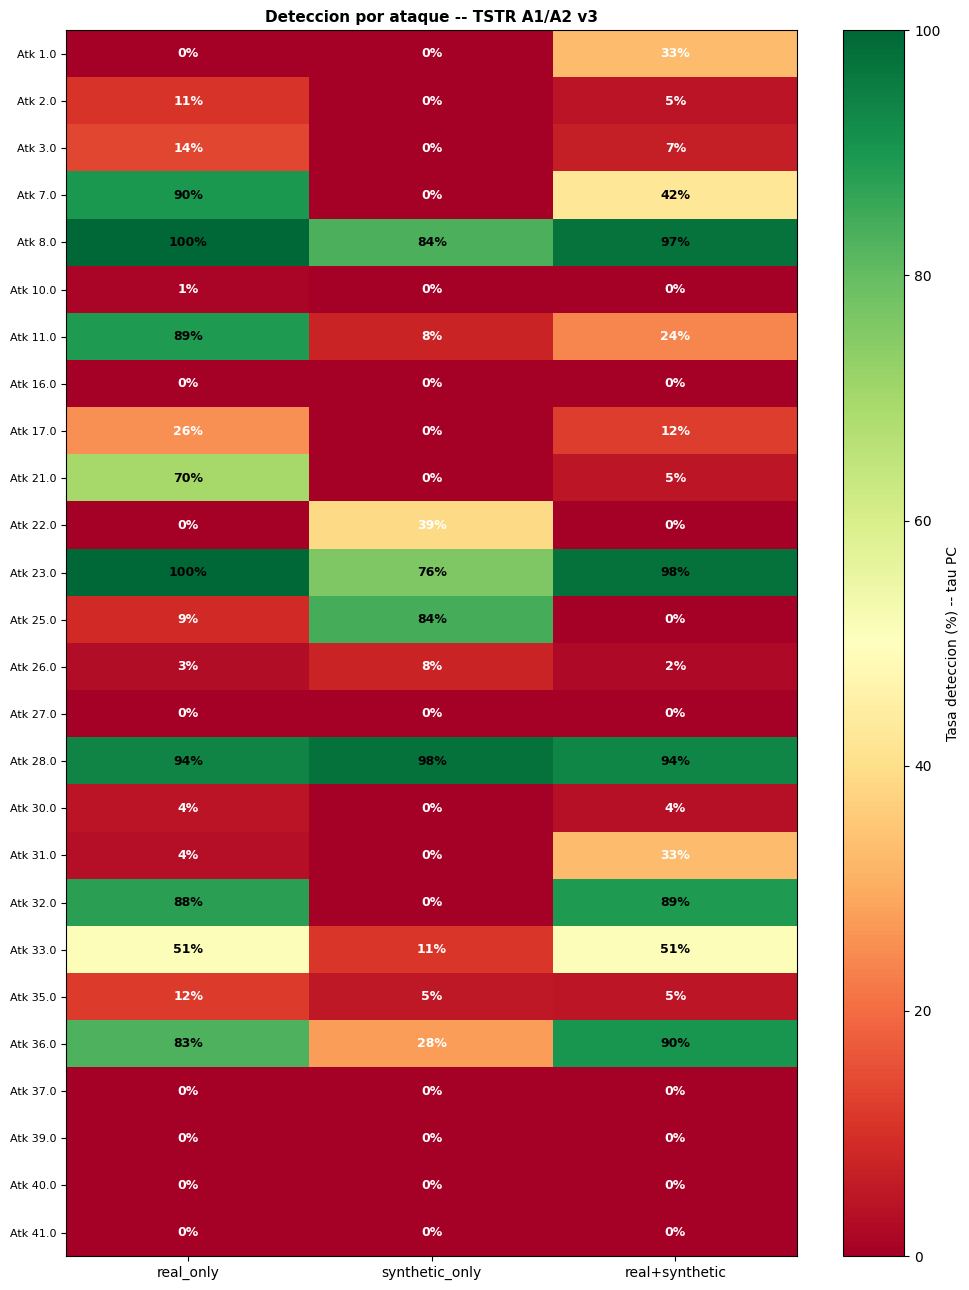

In [23]:
# Heatmap de deteccion por ataque (tau PC)
det_rows = []
for aid in sorted(EVALUABLE_ATK_IDS):
    n_t = (df_wins['attack_id']==aid).sum()
    row = {'attack_id': aid, 'n': n_t}
    for lbl in R_KEYS:
        det_tmp = RES[lbl]['df_ev_tmp']
        mask    = det_tmp['attack_id'] == aid
        if mask.sum() == 0:
            row[f'det_{lbl}'] = 0.0
        else:
            row[f'det_{lbl}'] = round(100*det_tmp.loc[mask,'pred_pc'].sum()/mask.sum(), 1)
    det_rows.append(row)
df_det = pd.DataFrame(det_rows)
print(df_det.to_string(index=False))

heat = df_det[['det_real_only','det_synthetic_only','det_real_plus_synthetic']].values
fig, ax = plt.subplots(figsize=(10, max(4, len(df_det)*0.5)))
im = ax.imshow(heat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks([0,1,2])
ax.set_xticklabels(['real_only','synthetic_only','real+synthetic'], fontsize=10)
ax.set_yticks(range(len(df_det)))
ax.set_yticklabels([f'Atk {r["attack_id"]}' for _,r in df_det.iterrows()], fontsize=8)
for ii in range(len(df_det)):
    for jj in range(3):
        ax.text(jj, ii, f'{heat[ii,jj]:.0f}%', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if heat[ii,jj]<40 else 'black')
plt.colorbar(im, ax=ax, label='Tasa deteccion (%) -- tau PC')
ax.set_title('Deteccion por ataque -- TSTR A1/A2 v3', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'deteccion_heatmap.png'), dpi=130, bbox_inches='tight')
plt.show()
df_det.to_csv(TSTR_DIR / 'deteccion_por_tipo.csv', index=False)


## 16. Metricas de agrupacion no supervisada (clustering)

Evaluan si el espacio latente del modelo separa correctamente datos normales de anomalos.
Se usan representaciones del espacio latente (mu del encoder) de ventanas normales vs ataque.

| Metrica | Interpretacion | Mejor cuando |
|---|---|---|
| **Silhouette** | Cohesion intra-cluster vs separacion inter | Alto (max 1.0) |
| **Calinski-Harabasz (CHI)** | Razon dispersion entre/intra | Alto |
| **Davies-Bouldin (DBI)** | Similitud promedio entre clusters | Bajo (min 0) |
| **Separacion de scores** | Ratio MAE_ataque / MAE_normal | Alto (>2.0 ideal) |


In [24]:
def get_latent_repr(model, Xc, Xd, bs=512):
    """Extrae representacion latente (mu del encoder) para clustering."""
    ldr = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                   torch.tensor(Xd, dtype=torch.float32)),
                     batch_size=bs, shuffle=False)
    mus = []
    model.eval()
    with torch.no_grad():
        for xc_b, xd_b in ldr:
            xc_b, xd_b = xc_b.to(device), xd_b.to(device)
            mu, _ = model.encoder_cont(xc_b)
            mus.extend(mu.cpu().numpy())
    return np.array(mus)

clustering_rows = []
print('='*65)
print('METRICAS DE AGRUPACION NO SUPERVISADA (espacio latente)')
print('='*65)
print(f'{"Escenario":<28} {"Silhouette":>12} {"CHI":>10} {"DBI":>8} {"Ratio":>8}')
print('-'*70)

for mdl, lbl in [
    (m_real_ev,  'real_only'),
    (m_synth_ev, 'synthetic_only'),
    (m_comb_ev,  'real_plus_synthetic'),
]:
    # Representaciones latentes de eval (subset para velocidad)
    n_sample = min(10000, len(X_eval_c))
    idx_s    = np.random.default_rng(SEED).choice(len(X_eval_c), n_sample, replace=False)
    Xc_s = X_eval_c[idx_s]; Xd_s = X_eval_d[idx_s]; y_s = y_all[idx_s]

    Z = get_latent_repr(mdl, Xc_s, Xd_s)   # (n_sample, latent_dim)

    # Reducir a 50 dims con PCA para speed
    pca_dim = min(50, Z.shape[1])
    Z_pca = PCA(n_components=pca_dim, random_state=SEED).fit_transform(Z)

    # Scores de agrupacion (normal=0, ataque=1)
    labels_binary = y_s
    if labels_binary.sum() > 10 and (labels_binary==0).sum() > 10:
        sil = silhouette_score(Z_pca, labels_binary, sample_size=5000, random_state=SEED)
        chi = calinski_harabasz_score(Z_pca, labels_binary)
        dbi = davies_bouldin_score(Z_pca, labels_binary)
    else:
        sil = chi = dbi = float('nan')

    # Ratio de separacion de scores
    sc_full = RES[lbl]['sc_all']
    ratio = float(sc_full[y_all==1].mean() / sc_full[y_all==0].mean())

    print(f'  {lbl:<26} {sil:>12.4f} {chi:>10.1f} {dbi:>8.4f} {ratio:>8.3f}x')
    clustering_rows.append({
        'escenario': lbl, 'silhouette': round(float(sil),4),
        'calinski_harabasz': round(float(chi),2),
        'davies_bouldin': round(float(dbi),4), 'ratio_scores': round(ratio,3)
    })

print('='*65)
print('Silhouette: mayor es mejor (max 1.0)')
print('CHI: mayor es mejor | DBI: menor es mejor (min 0)')
print('Ratio: MAE_ataque / MAE_normal -- mayor = mejor discriminacion')
df_clustering = pd.DataFrame(clustering_rows)
df_clustering.to_csv(TSTR_DIR / 'clustering_metrics.csv', index=False)


METRICAS DE AGRUPACION NO SUPERVISADA (espacio latente)
Escenario                      Silhouette        CHI      DBI    Ratio
----------------------------------------------------------------------
  real_only                        0.2647     1382.4   1.7722    2.207x
  synthetic_only                   0.0558      129.2   4.2426    1.573x
  real_plus_synthetic              0.1537      643.9   2.4823    1.943x
Silhouette: mayor es mejor (max 1.0)
CHI: mayor es mejor | DBI: menor es mejor (min 0)
Ratio: MAE_ataque / MAE_normal -- mayor = mejor discriminacion


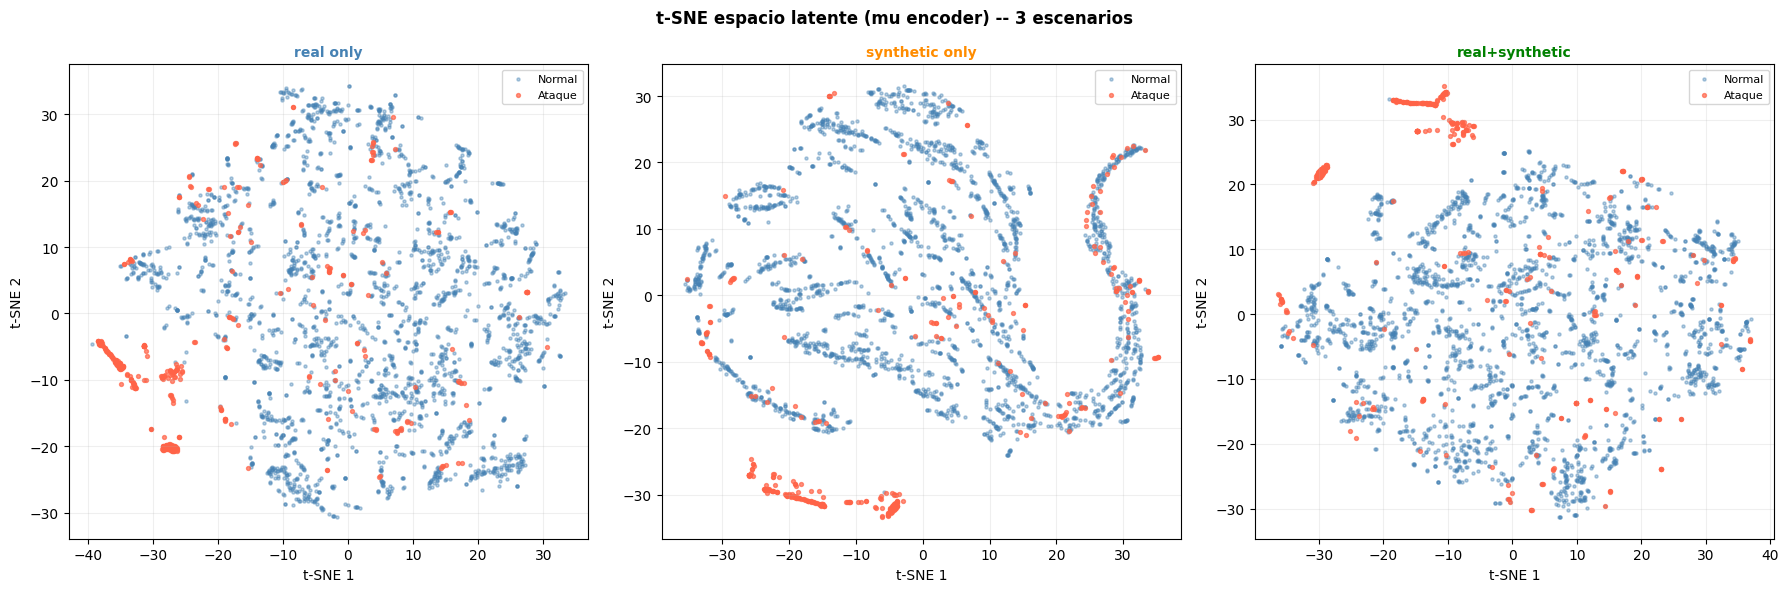

In [25]:
# t-SNE del espacio latente para los 3 escenarios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
n_tsne = min(3000, len(X_eval_c))
idx_t  = np.random.default_rng(SEED+1).choice(len(X_eval_c), n_tsne, replace=False)
Xc_t = X_eval_c[idx_t]; Xd_t = X_eval_d[idx_t]; y_t = y_all[idx_t]

for ax, (mdl, lbl, col) in zip(axes, [
    (m_real_ev,  'real_only',      'steelblue'),
    (m_synth_ev, 'synthetic_only', 'darkorange'),
    (m_comb_ev,  'real+synthetic', 'green'),
]):
    Z = get_latent_repr(mdl, Xc_t, Xd_t)
    Z2 = TSNE(n_components=2, random_state=SEED, perplexity=40, max_iter=500).fit_transform(Z)
    ax.scatter(Z2[y_t==0,0], Z2[y_t==0,1], s=5, alpha=0.4, color='steelblue', label='Normal')
    ax.scatter(Z2[y_t==1,0], Z2[y_t==1,1], s=8, alpha=0.7, color='tomato',    label='Ataque')
    ax.set_title(lbl.replace('_',' '), fontsize=10, fontweight='bold', color=col)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.suptitle('t-SNE espacio latente (mu encoder) -- 3 escenarios', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'tsne_latent.png'), dpi=130, bbox_inches='tight')
plt.show()


## 17. Guardar resultados

In [26]:
tstr_cfg = {
    'version'        : 'lstm_vae_tstr_a1a2_v3',
    'baseline'       : 'lstm_vae_swat_a1a2_baseline_v3',
    'timegan_version': TIMEGAN_VERSION,
    'eval_protocol'  : {
        'excluded_attacks': EXCLUDED_ATTACKS,
        'evaluable_attacks': EVALUABLE_ATK_IDS,
        'k': CONSEC_K, 'min_prec': MIN_PREC,
        'stride_eval': STRIDE_EVAL,
    },
    'train_windows': {
        'real_only': len(X_tr_c), 'synthetic_only': len(X_sy_c),
        'real_plus_synthetic': len(X_co_c),
    },
    'best_epochs': {'real_only': ep_r, 'synthetic_only': ep_s, 'real_plus_synthetic': ep_c},
    'results': {
        lbl: {
            'roc_auc': RES[lbl]['roc_auc'], 'pr_auc': RES[lbl]['pr_auc'],
            'ratio': RES[lbl]['ratio'],
            'tau_f1': RES[lbl]['f1_tau'], 'tau_pc': RES[lbl]['pc_tau'],
            'tau_f2': RES[lbl]['f2_tau'],
            'det_f1': RES[lbl]['det_f1'], 'det_pc': RES[lbl]['det_pc'],
            'det_f2': RES[lbl]['det_f2'],
        } for lbl in R_KEYS
    },
    'clustering': df_clustering.to_dict('records'),
    'delta_vs_real_only_pc': {
        lbl: {
            'delta_auc': round(RES[lbl]['roc_auc']-RES['real_only']['roc_auc'], 4),
            'delta_f1':  round(RES[lbl]['pc_tau']['f1']-RES['real_only']['pc_tau']['f1'], 3),
            'delta_rec': round(RES[lbl]['pc_tau']['recall']-RES['real_only']['pc_tau']['recall'], 3),
            'delta_det': RES[lbl]['det_pc'] - RES['real_only']['det_pc'],
        } for lbl in ['synthetic_only', 'real_plus_synthetic']
    },
    'pinto_reference': {'auc': 0.87, 'f1': 0.74, 'recall': 0.78, 'precision': 0.70, 'det': 23},
}
with open(TSTR_DIR / 'tstr_results.json', 'w') as f:
    json.dump(tstr_cfg, f, indent=4)

print('Guardado en:', TSTR_DIR.resolve())
for fp_ in sorted(TSTR_DIR.iterdir()):
    print(f'  {fp_.name}')
print()
print('='*70)
print('RESUMEN FINAL -- TSTR A1/A2 v3 (tau PC)')
print('='*70)
for lbl in R_KEYS:
    r = RES[lbl]; m = r['pc_tau']
    print(f'  {lbl:<25}: AUC={r["roc_auc"]:.4f} F1={m["f1"]:.3f} '
          f'Rec={m["recall"]:.3f} Prec={m["precision"]:.3f} det={r["det_pc"]}/26')
print()
d = tstr_cfg['delta_vs_real_only_pc']
print('Delta real+synth vs real_only:')
for lbl in ['synthetic_only', 'real_plus_synthetic']:
    dd = d[lbl]
    print(f'  {lbl:<25}: DAUC={dd["delta_auc"]:+.4f} DF1={dd["delta_f1"]:+.3f} '
          f'DRec={dd["delta_rec"]:+.3f} Ddet={dd["delta_det"]:+d}')
print()
print('Referencia Pinto et al.: AUC=0.87 | F1=0.74 | Rec=0.78 | Prec=0.70 | det=23/26')
print('='*70)


Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr_a1a2_v6_lstm_vae_a1a2_baseline_v4
  clustering_metrics.csv
  deteccion_heatmap.png
  deteccion_por_tipo.csv
  dist_real_vs_synth.png
  metricas_comparativas.png
  model_real_only.pt
  model_real_plus_synthetic.pt
  model_synthetic_only.pt
  roc_pr_comparison.png
  score_distributions.png
  score_temporal.png
  tabla_comparativa.csv
  training_curves.png
  tsne_latent.png
  tstr_results.json

RESUMEN FINAL -- TSTR A1/A2 v3 (tau PC)
  real_only                : AUC=0.9393 F1=0.738 Rec=0.761 Prec=0.716 det=18/26
  synthetic_only           : AUC=0.8901 F1=0.729 Rec=0.742 Prec=0.717 det=10/26
  real_plus_synthetic      : AUC=0.9215 F1=0.727 Rec=0.741 Prec=0.714 det=17/26

Delta real+synth vs real_only:
  synthetic_only           : DAUC=-0.0491 DF1=-0.009 DRec=-0.020 Ddet=-8
  real_plus_synthetic      : DAUC=-0.0177 DF1=-0.011 DRec=-0.021 Ddet=-1

Ref